In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


In [ ]:
def normalize_province_name(s):
    if pd.isna(s):
        return s
    s = str(s).strip()
    s = s.replace("İ", "i").replace("I", "i").replace("ı","i")
    return s.lower()


In [ ]:
mig_path = "/migration_province_year_2008_2024 (1).csv"
mig = pd.read_csv(mig_path)

mig["province"] = mig["province"].apply(normalize_province_name)

mig


,year,province,in_migration,out_migration,net_migration,out_migration_growth
0,2008,adana,45493,58316,-12823,NaN
1,2009,adana,53685,54109,-424,-7.214144
2,2010,adana,53096,57402,-4306,6.085864
3,2011,adana,50523,62402,-11879,8.710498
4,2012,adana,45927,59294,-13367,-4.980610
...,...,...,...,...,...,...
1372,2020,şirnak,14461,15008,-547,-27.581548
1373,2021,şirnak,17072,20431,-3359,36.134062
1374,2022,şirnak,20096,23469,-3373,14.869561
1375,2023,şirnak,22726,21572,1154,-8.083003


In [ ]:
events_path = "/event_list_2008plus_with_tuik_names_MINOR_ADDED.csv"
events = pd.read_csv(events_path)

events["t0"] = pd.to_datetime(events["t0"], errors="coerce")
events["t0_year"] = events["t0"].dt.year

events["province"] = events["province"].apply(normalize_province_name)

events


,province,disaster_type,event_name,t0,severity_class,province_tuik,t0_year
0,istanbul,Earthquake,2019 Silivri Offshore / Marmara Sea Earthquake...,2019-09-26,minor,İSTANBUL,2019
1,izmir,Earthquake,2020 Aegean Sea “Samos (Sisam) / Seferihisar” ...,2020-10-30,major,İZMİR,2020
2,elaziğ,Earthquake,2020 Elazığ–Sivrice Earthquake (Mw 6.8),2020-01-24,major,ELAZIĞ,2020
3,van,Earthquake,2011 Van–Erciş Earthquake (Mw 7.2),2011-10-23,major,VAN,2011
4,kahramanmaraş,Earthquake,6 Feb 2023 Kahramanmaraş Earthquakes (Mw 7.7 /...,2023-02-06,major,KAHRAMANMARAŞ,2023
5,hatay,Earthquake,6 Feb 2023 Kahramanmaraş Earthquakes (Hatay im...,2023-02-06,major,HATAY,2023
6,kastamonu,Flood,11 Aug 2021 Western Black Sea Flood (Bozkurt),2021-08-11,NaN,KASTAMONU,2021
7,sinop,Flood,11 Aug 2021 Western Black Sea Flood (Ayancık),2021-08-11,NaN,SİNOP,2021
8,antalya,Wildfire,2021 Manavgat Wildfire,2021-07-28,NaN,ANTALYA,2021
9,muğla,Wildfire,2021 Marmaris Wildfire,2021-07-29,NaN,MUĞLA,2021


In [ ]:
missing = sorted(set(events["province"]) - set(mig["province"]))
extra   = sorted(set(mig["province"]) - set(events["province"]))

print("Events'te olup migration'da olmayan iller:", missing[:20], "..." if len(missing)>20 else "")
print("Migration'da olup events'te olmayan iller (normal olabilir):", extra[:10], "...")


Events'te olup migration'da olmayan iller: [] 
Migration'da olup events'te olmayan iller (normal olabilir): ['adana', 'adiyaman', 'afyonkarahisar', 'aksaray', 'amasya', 'ankara', 'ardahan', 'artvin', 'ağri', 'balikesir'] ...


In [ ]:
def build_prepost_table(mig_df, events_df, outcomes=None):
    if outcomes is None:
        outcomes = ["out_migration", "net_migration", "out_migration_growth"]

    rows = []

    for _, e in events_df.iterrows():
        prov = e["province"]
        t0y  = int(e["t0_year"])

        pre_years = [t0y - 2, t0y - 1]
        post_years = [t0y + 1, t0y + 2]

        sub = mig_df[mig_df["province"] == prov]

        pre_df = sub[sub["year"].isin(pre_years)]
        post_df = sub[sub["year"].isin(post_years)]

        row = {
            "province": prov,
            "t0_year": t0y,
            "t0": e.get("t0", pd.NaT),
            "disaster_type": e.get("disaster_type", np.nan),
            "event_name": e.get("event_name", np.nan),
            "severity_class": e.get("severity_class", np.nan),
            "pre_years": ",".join(map(str, pre_years)),
            "post_years": ",".join(map(str, post_years)),
            "n_pre": len(pre_df),
            "n_post": len(post_df),
        }

        for col in outcomes:
            pre_mean = pre_df[col].mean()
            post_mean = post_df[col].mean()
            row[f"pre_{col}"] = pre_mean
            row[f"post_{col}"] = post_mean
            row[f"delta_{col}"] = post_mean - pre_mean

        rows.append(row)

    return pd.DataFrame(rows)


In [ ]:
prepost = build_prepost_table(mig, events)

prepost = prepost.sort_values(["disaster_type", "province", "t0_year"]).reset_index(drop=True)
prepost[["province","disaster_type","t0_year","n_pre","n_post","delta_out_migration_growth","delta_net_migration"]]


,province,disaster_type,t0_year,n_pre,n_post,delta_out_migration_growth,delta_net_migration
0,elaziğ,Earthquake,2020,2,2,-12.629976,135.5
1,hatay,Earthquake,2023,2,1,-101.945338,12927.5
2,istanbul,Earthquake,2019,2,2,-14.504827,70217.0
3,istanbul,Earthquake,2020,2,2,2.441123,17162.5
4,izmir,Earthquake,2020,2,2,5.638931,6292.0
5,izmir,Earthquake,2021,2,2,18.697796,5494.5
6,izmir,Earthquake,2022,2,2,-3.308895,637.5
7,kahramanmaraş,Earthquake,2023,2,1,-86.598985,13921.5
8,van,Earthquake,2011,2,2,-28.944212,4682.5
9,kastamonu,Flood,2021,2,2,6.043143,11122.0


In [ ]:
eq = prepost[prepost["disaster_type"].str.lower().eq("earthquake")].copy()
eq = eq.dropna(subset=["severity_class", "delta_out_migration_growth"])

eq.groupby("severity_class")["delta_out_migration_growth"].agg(["count","mean","median","std"])


,count,mean,median,std
severity_class,,,,
major,5,-44.895916,-28.944212,47.018882
minor,4,0.831299,-0.433886,13.834031


/tmp/ipython-input-3046915910.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([major, minor], labels=["major","minor"])


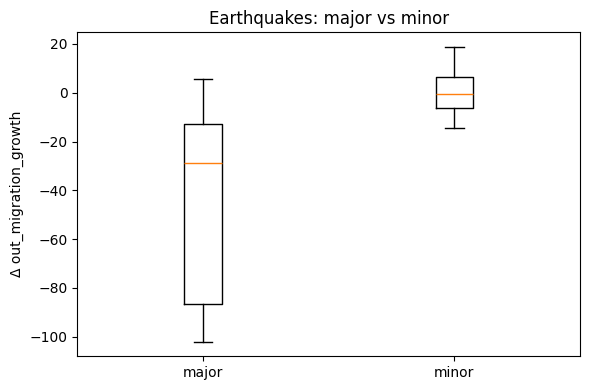

In [ ]:
major = eq.loc[eq["severity_class"]=="major", "delta_out_migration_growth"].dropna()
minor = eq.loc[eq["severity_class"]=="minor", "delta_out_migration_growth"].dropna()

plt.figure(figsize=(6,4))
plt.boxplot([major, minor], labels=["major","minor"])
plt.ylabel("Δ out_migration_growth")
plt.title("Earthquakes: major vs minor")
plt.tight_layout()
plt.show()


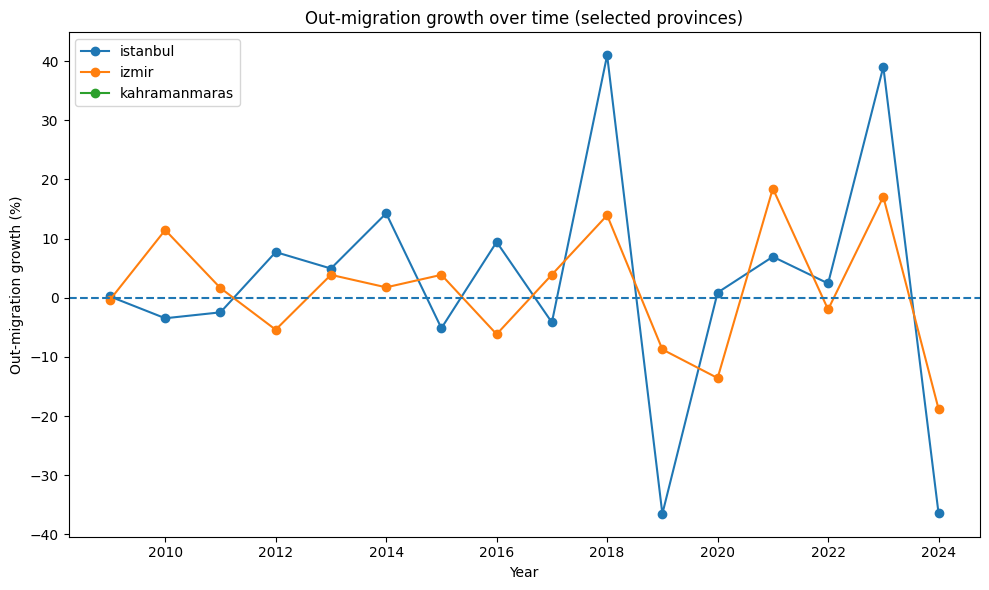

In [ ]:
sample_provinces = ["istanbul", "izmir", "kahramanmaras"]

plt.figure(figsize=(10,6))
for p in sample_provinces:
    sub = mig[mig["province"] == p]
    plt.plot(sub["year"], sub["out_migration_growth"], marker="o", label=p)

plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Out-migration growth over time (selected provinces)")
plt.xlabel("Year")
plt.ylabel("Out-migration growth (%)")
plt.tight_layout()
plt.show()


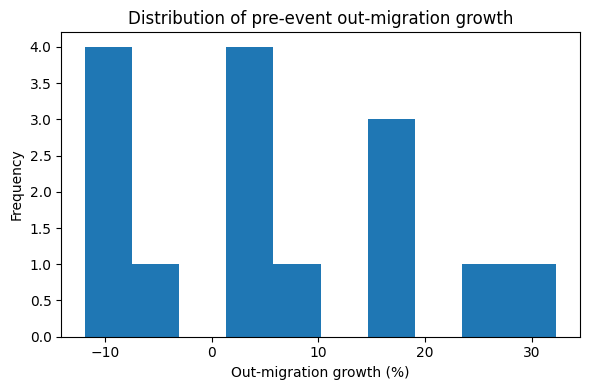

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(prepost["pre_out_migration_growth"].dropna(), bins=10)
plt.title("Distribution of pre-event out-migration growth")
plt.xlabel("Out-migration growth (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


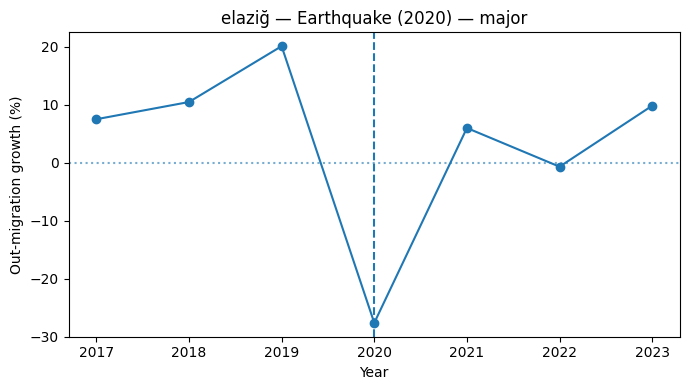

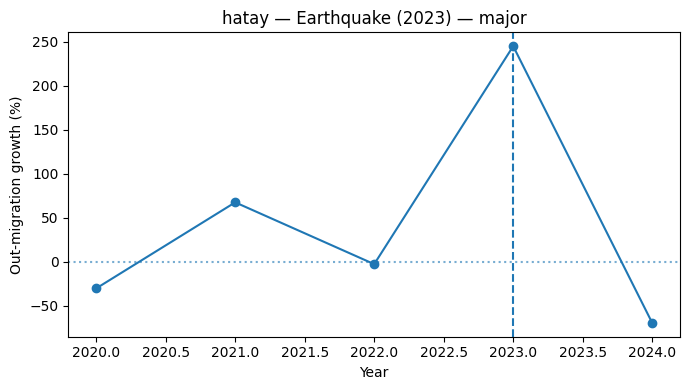

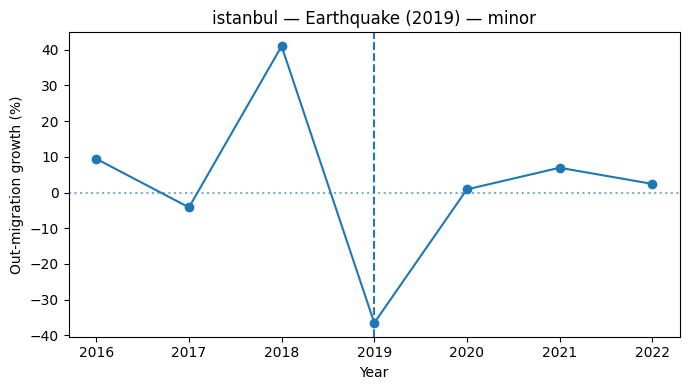

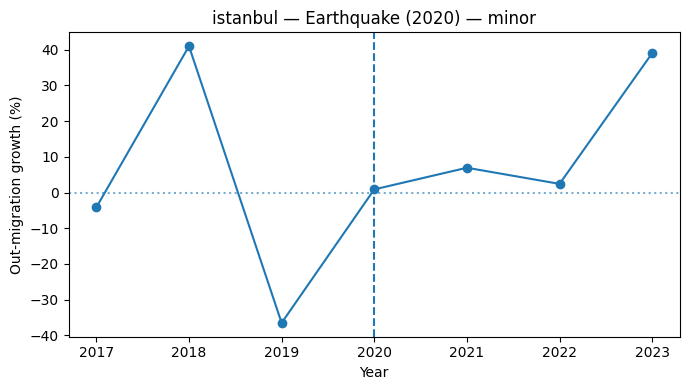

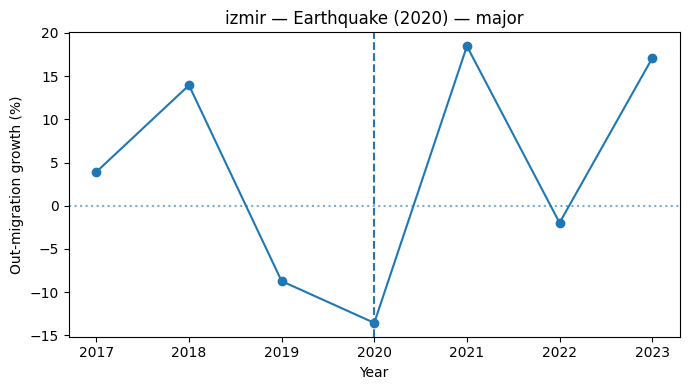

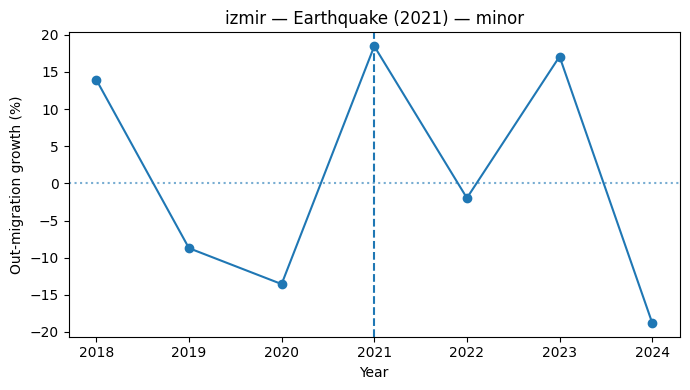

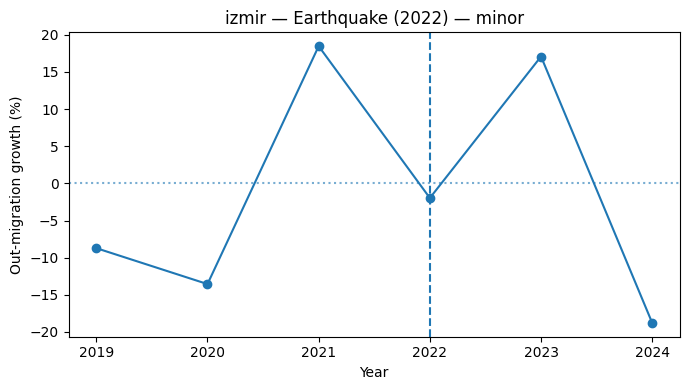

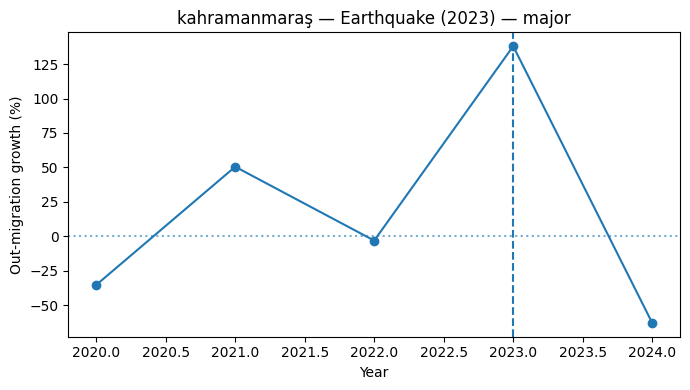

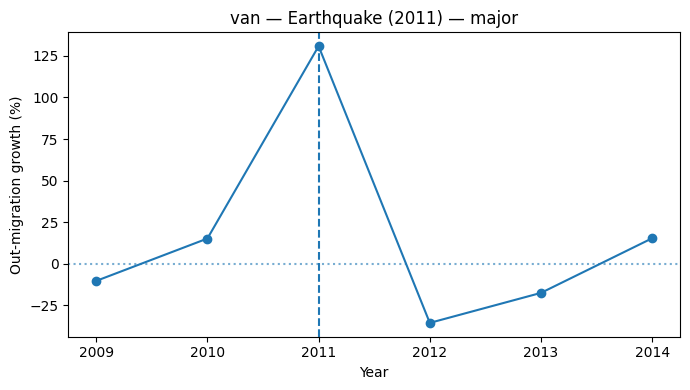

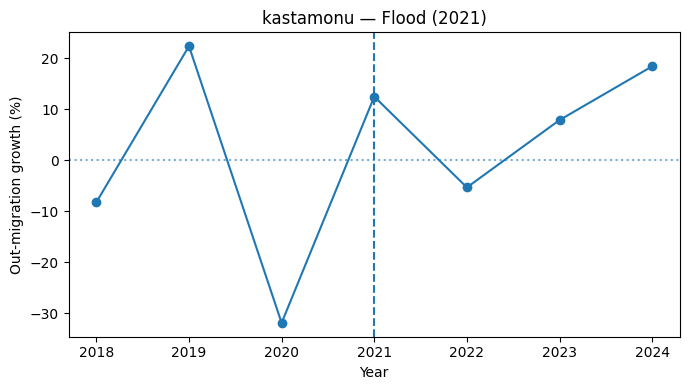

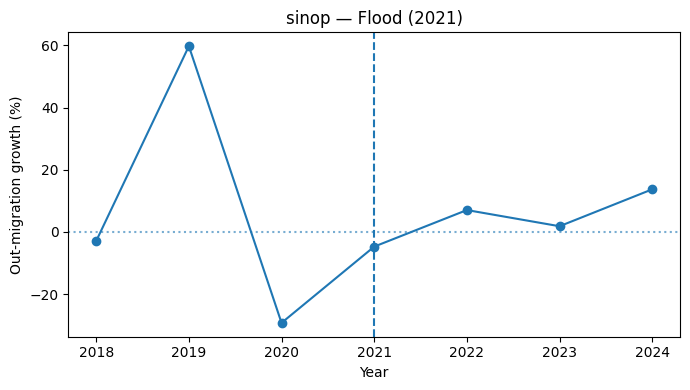

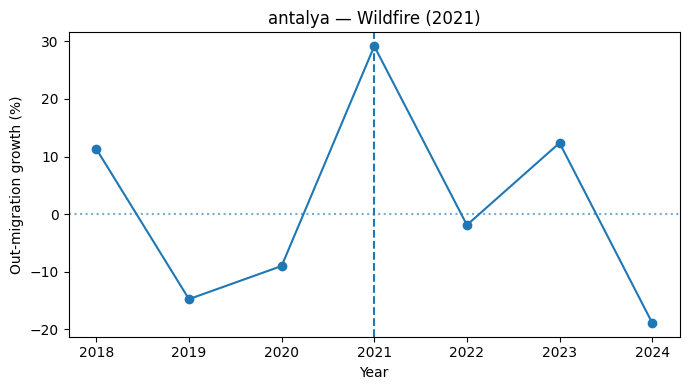

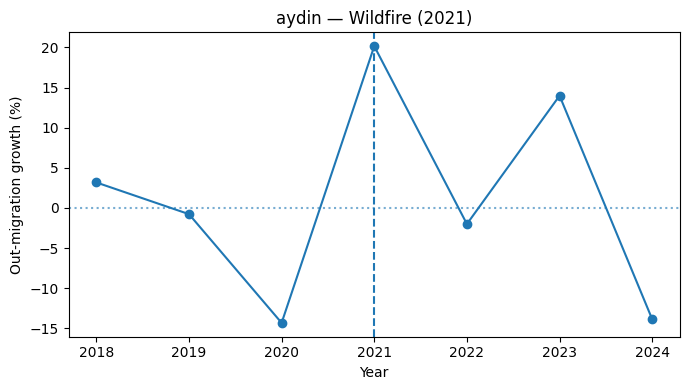

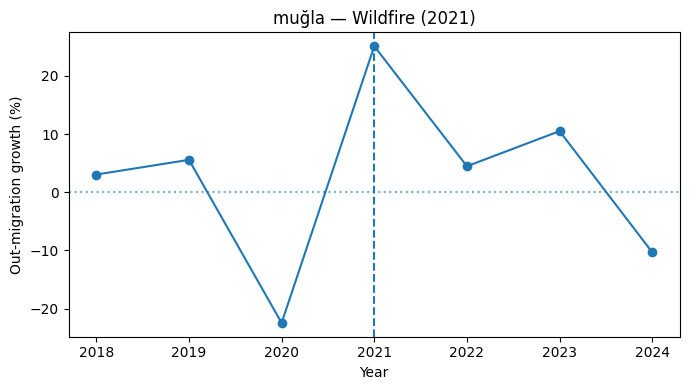

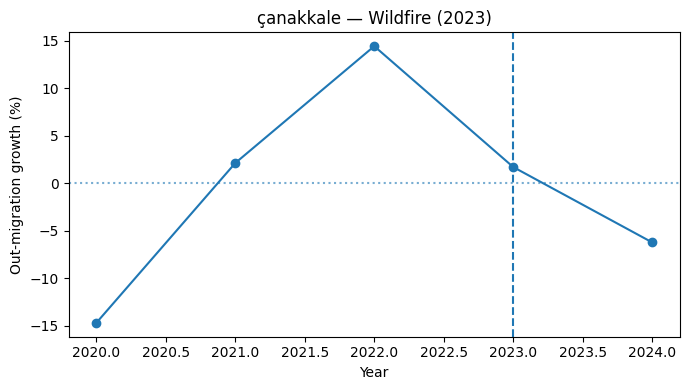

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- your normalization (as you implemented) ---
def normalize_province_name(s):
    if pd.isna(s):
        return s
    s = str(s).strip()
    s = s.replace("İ", "i").replace("I", "i").replace("ı","i")
    return s.lower()

# --- paths (edit if needed) ---
MIG_PATH = "/migration_province_year_2008_2024 (1).csv"
EVENTS_PATH = "/event_list_2008plus_with_tuik_names_MINOR_ADDED.csv"

# --- load data ---
mig = pd.read_csv(MIG_PATH)
events = pd.read_csv(EVENTS_PATH)

# --- basic cleaning / normalization ---
mig["province"] = mig["province"].apply(normalize_province_name)
mig["year"] = pd.to_numeric(mig["year"], errors="coerce").astype(int)

events["province"] = events["province"].apply(normalize_province_name)
events["t0"] = pd.to_datetime(events["t0"], errors="coerce")
events["t0_year"] = events["t0"].dt.year.astype(int)

# --- quick match check (optional but useful) ---
missing = sorted(set(events["province"]) - set(mig["province"]))
if missing:
    print("WARNING: These event provinces are missing in migration data:", missing)

# --- plot function ---
def plot_event_prepost(mig_df, event_row, window=3, y_col="out_migration_growth"):
    prov = event_row["province"]
    t0y = int(event_row["t0_year"])
    dtype = str(event_row.get("disaster_type", ""))
    sev = event_row.get("severity_class", "")

    sub = mig_df[mig_df["province"] == prov].copy()
    sub = sub[(sub["year"] >= t0y - window) & (sub["year"] <= t0y + window)]
    sub = sub.sort_values("year")

    plt.figure(figsize=(7, 4))
    plt.plot(sub["year"], sub[y_col], marker="o")
    plt.axvline(t0y, linestyle="--")          # event year
    plt.axhline(0, linestyle=":", alpha=0.6)  # zero line

    title = f"{prov} — {dtype} ({t0y})"
    if isinstance(sev, str) and sev.strip() != "" and sev.lower() != "nan":
        title += f" — {sev}"
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("Out-migration growth (%)")
    plt.tight_layout()
    plt.show()

# --- generate plots for ALL events ---
for _, e in events.sort_values(["disaster_type", "province", "t0_year"]).iterrows():
    plot_event_prepost(mig, e, window=3, y_col="out_migration_growth")


In [32]:
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler # StandardScaler eklendi
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# ---- 1) Prepare ML dataset from prepost ----
# 'prepost' dataframe'inin hafızada yüklü olduğu varsayılmıştır.
if 'prepost' not in locals():
    raise ValueError("Lütfen önce 'prepost' verisini yükleyin veya oluşturun.")

ml_df = prepost.copy()

# Make sure severity exists for non-earthquakes
if "severity_class" not in ml_df.columns:
    ml_df["severity_class"] = np.nan

# Ensure consistent casing and type
ml_df["disaster_type"] = ml_df["disaster_type"].astype(str)
ml_df["severity_class"] = ml_df["severity_class"].astype(str)

# Handle non-earthquake severity
ml_df.loc[ml_df["disaster_type"].str.lower() != "earthquake", "severity_class"] = "na"
# "nan" string'ini tekrar gerçek NaN yapıp simple imputer'a bırakabiliriz veya "na" kategorisi olarak tutabiliriz.
# Burada "na" string olarak tutuyoruz ki ayrı bir kategori olsun.

# Target
TARGET = "delta_out_migration_growth"
ml_df = ml_df.dropna(subset=[TARGET]).reset_index(drop=True)

# Features
FEATURES = [
    "disaster_type",
    "severity_class",
    "province",
    "t0_year",
    "pre_out_migration_growth",  # baseline trend
    "pre_net_migration",         # baseline net
]
# keep only existing cols
FEATURES = [c for c in FEATURES if c in ml_df.columns]

X = ml_df[FEATURES].copy()
y = ml_df[TARGET].astype(float).values

# Identify categorical vs numeric
cat_cols = [c for c in FEATURES if X[c].dtype == "object" or X[c].dtype.name == 'category']
num_cols = [c for c in FEATURES if c not in cat_cols]

print(f"Features: {len(FEATURES)}")
print(f"Categorical: {cat_cols}")
print(f"Numeric: {num_cols}")

# Preprocessing Pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()) # <--- EKLENDİ: Ridge için kritiktir!
        ]), num_cols),
    ],
    remainder="drop"
)

loo = LeaveOneOut()

# ==========================================
# ---- 2) Model A: Ridge (interpretable baseline) ----
# ==========================================

ridge = Pipeline(steps=[
    ("prep", preprocess),
    ("model", Ridge(alpha=1.0, random_state=42))
])

print("Running Ridge LOOCV...")
# EKSİK OLAN KISIM EKLENDİ: Tahminleri alıyoruz
ridge_pred = cross_val_predict(ridge, X, y, cv=loo, n_jobs=-1)

ridge_mae = mean_absolute_error(y, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y, ridge_pred))
ridge_r2 = r2_score(y, ridge_pred)

print("=== Ridge (LOOCV) ===")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R^2 :", ridge_r2)

# Fit on full data for coefficient inspection
ridge.fit(X, y)

# Get feature names after one-hot
try:
    ohe = ridge.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
    ohe_names = list(ohe.get_feature_names_out(cat_cols)) if len(cat_cols) else []
except AttributeError:
    ohe_names = [] # Hata durumunda boş liste
feat_names = ohe_names + num_cols

ridge_coefs = ridge.named_steps["model"].coef_

# Boyut kontrolü (bazen feature sayısı uyuşmayabilir, kontrol ediyoruz)
if len(feat_names) == len(ridge_coefs):
    coef_df = pd.DataFrame({"feature": feat_names, "coef": ridge_coefs})
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)
    print("\nTop Ridge coefficients (by absolute value):")
    print(coef_df.head(15)[["feature", "coef"]])
else:
    print("\nWarning: Feature names count mismatch with coefficients.")

# ==========================================
# ---- 3) Model B: Random Forest (nonlinear check) ----
# ==========================================

rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        min_samples_leaf=1,
        n_jobs=-1 # Hızlandırma için
    ))
])

print("\nRunning Random Forest LOOCV (this may take a moment)...")
# EKSİK OLAN KISIM EKLENDİ: Tahminleri alıyoruz
rf_pred = cross_val_predict(rf, X, y, cv=loo, n_jobs=-1)

rf_mae = mean_absolute_error(y, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y, rf_pred))
rf_r2 = r2_score(y, rf_pred)

print("=== Random Forest (LOOCV) ===")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R^2 :", rf_r2)


# Fit on full data to get feature importances
rf.fit(X, y)
rf_model = rf.named_steps["model"]

# For RF importances
rf_imp = rf_model.feature_importances_
if len(feat_names) == len(rf_imp):
    imp_df = pd.DataFrame({"feature": feat_names, "importance": rf_imp}).sort_values("importance", ascending=False)
    print("\nTop RF feature importances:")
    print(imp_df.head(15))
else:
    imp_df = pd.DataFrame() # Boş

# ==========================================
# ---- 4) Save ML outputs ----
# ==========================================

ml_out = ml_df[["province", "disaster_type", "severity_class", "t0_year", TARGET]].copy()
ml_out["pred_ridge_loocv"] = ridge_pred
ml_out["pred_rf_loocv"] = rf_pred
ml_out["abs_error_ridge"] = (ml_out[TARGET] - ml_out["pred_ridge_loocv"]).abs()
ml_out["abs_error_rf"] = (ml_out[TARGET] - ml_out["pred_rf_loocv"]).abs()

ml_out_path = "data/processed/ml_predictions_loocv.csv"
coef_path = "data/processed/ml_ridge_coefficients.csv"
imp_path = "data/processed/ml_rf_importances.csv"

# Create folder if needed
os.makedirs("data/processed", exist_ok=True)

ml_out.to_csv(ml_out_path, index=False, encoding="utf-8-sig")
if not coef_df.empty:
    coef_df.to_csv(coef_path, index=False, encoding="utf-8-sig")
if not imp_df.empty:
    imp_df.to_csv(imp_path, index=False, encoding="utf-8-sig")

print("\nSaved:")
print("-", ml_out_path)
print("-", coef_path)
print("-", imp_path)

Features: 6
Categorical: ['disaster_type', 'severity_class', 'province']
Numeric: ['t0_year', 'pre_out_migration_growth', 'pre_net_migration']
Running Ridge LOOCV...
=== Ridge (LOOCV) ===
MAE : 24.15651582134857
RMSE: 42.637540142884006
R^2 : -0.5076982275235737

Top Ridge coefficients (by absolute value):
                     feature       coef
19  pre_out_migration_growth -22.738430
8            province_elaziğ  14.658726
9             province_hatay -14.197204
12    province_kahramanmaraş -13.956468
11            province_izmir  11.713619
16              province_van  -8.944697
3       severity_class_major  -6.724751
15            province_sinop   6.376089
10         province_istanbul   6.211629
5          severity_class_na   4.514396
0   disaster_type_Earthquake  -4.514396
20         pre_net_migration  -3.641971
1        disaster_type_Flood   3.464867
13        province_kastamonu  -2.911222
18                   t0_year  -2.424476

Running Random Forest LOOCV (this may take a moment

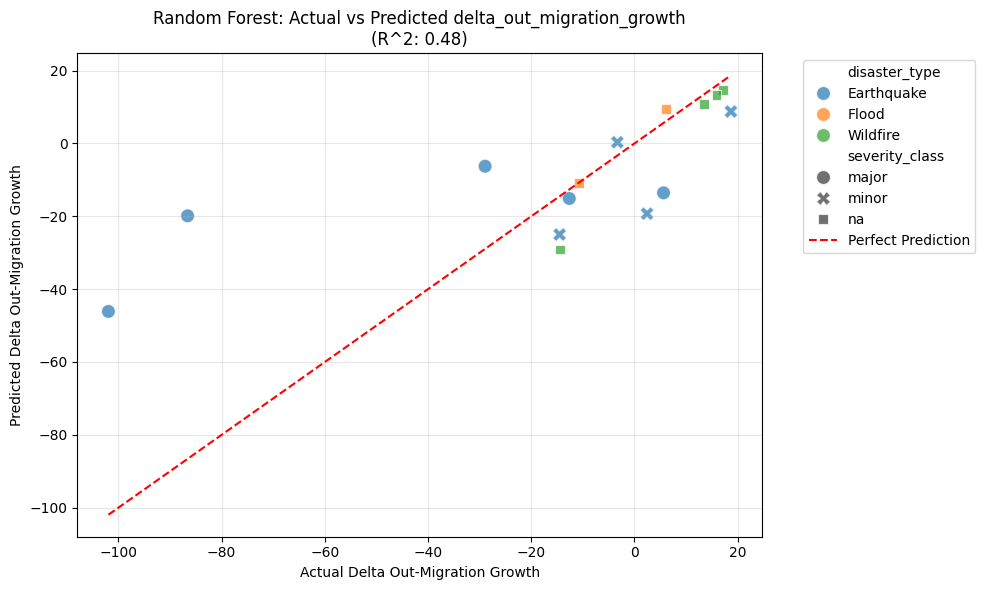


=== Top 10 Random Forest Errors ===
         province disaster_type  t0_year  delta_out_migration_growth  \
7   kahramanmaraş    Earthquake     2023                  -86.598985   
1           hatay    Earthquake     2023                 -101.945338   
8             van    Earthquake     2011                  -28.944212   
3        istanbul    Earthquake     2020                    2.441123   
4           izmir    Earthquake     2020                    5.638931   
14      çanakkale      Wildfire     2023                  -14.494100   
2        istanbul    Earthquake     2019                  -14.504827   
5           izmir    Earthquake     2021                   18.697796   
6           izmir    Earthquake     2022                   -3.308895   
9       kastamonu         Flood     2021                    6.043143   

    pred_rf_loocv   rf_error  
7      -19.870887  66.728098  
1      -46.113032  55.832306  
8       -6.252223  22.691989  
3      -19.277020 -21.718143  
4      -13.5656

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# CSV'yi tekrar yüklemeye gerek yok, 'ml_out' hafızada
# Ama dosyadan okumak isterseniz:
# ml_out = pd.read_csv("data/processed/ml_predictions_loocv.csv")

plt.figure(figsize=(10, 6))

# 1. Gerçek vs Tahmin (Random Forest)
sns.scatterplot(
    data=ml_out,
    x=TARGET,
    y="pred_rf_loocv",
    hue="disaster_type",
    style="severity_class",
    s=100,
    alpha=0.7
)

# Mükemmel tahmin çizgisi (y=x)
min_val = min(ml_out[TARGET].min(), ml_out["pred_rf_loocv"].min())
max_val = max(ml_out[TARGET].max(), ml_out["pred_rf_loocv"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction")

plt.title(f"Random Forest: Actual vs Predicted {TARGET}\n(R^2: {rf_r2:.2f})")
plt.xlabel("Actual Delta Out-Migration Growth")
plt.ylabel("Predicted Delta Out-Migration Growth")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. En Büyük Hatalar (Top 10 Misses)
ml_out["rf_error"] = ml_out["pred_rf_loocv"] - ml_out[TARGET] # Pozitifse fazla tahmin, negatifse eksik
top_errors = ml_out.reindex(ml_out["abs_error_rf"].sort_values(ascending=False).index).head(10)

print("\n=== Top 10 Random Forest Errors ===")
print(top_errors[["province", "disaster_type", "t0_year", TARGET, "pred_rf_loocv", "rf_error"]])